LINEAR REGRESSION RESULTS
MSE: 9.8522
MAE: 2.5065
R²:  0.9819


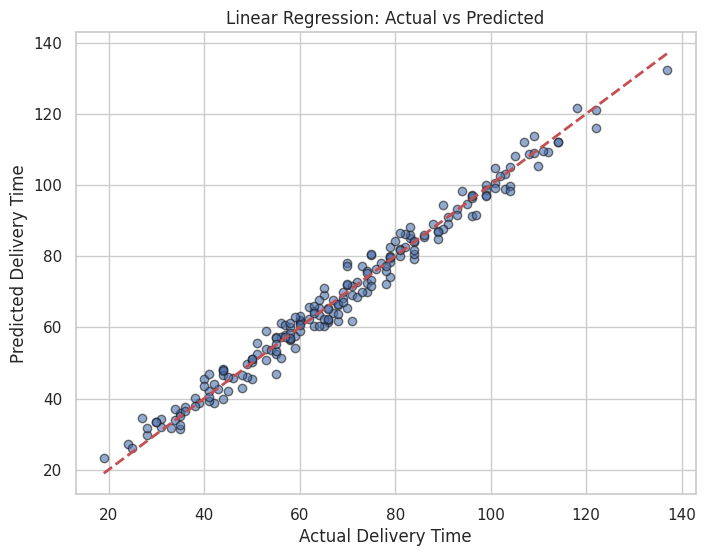


LOGISTIC REGRESSION RESULTS
Accuracy:  0.9650
Precision: 0.9537
Recall:    0.9810
F1-Score:  0.9671


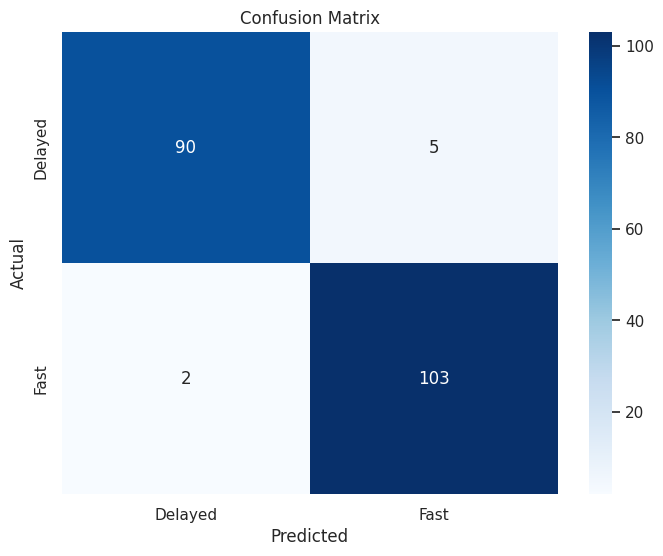

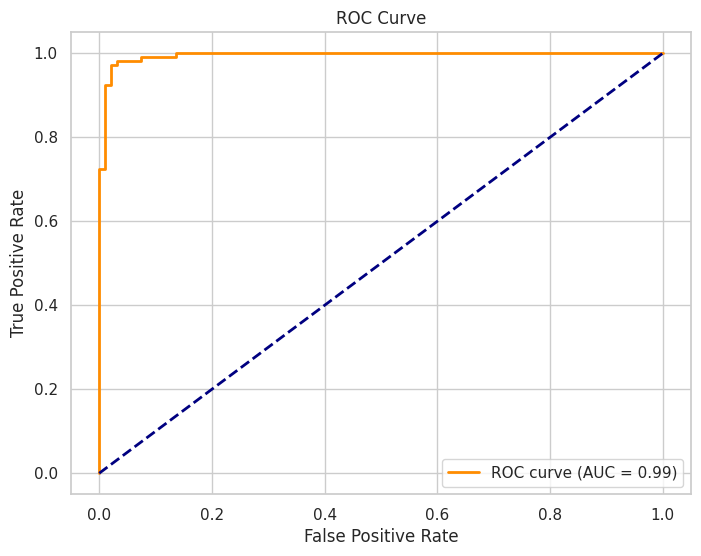


FINAL SUMMARY
Linear Regression - R²: 0.9819, MAE: 2.5065
Logistic Regression - Accuracy: 0.9650, AUC: 0.9946


In [ ]:
# Complete Food Delivery Analysis ---------> Aditya Sagar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
      accuracy_score, precision_score, recall_score, f1_score,
      confusion_matrix, classification_report, roc_curve, auc)

sns.set(style="whitegrid")


# ===================== DATASET CREATION =====================

np.random.seed(42)
n = 1000
data = {
    'Order_ID': [f'ORD{str(i).zfill(6)}' for i in range(1, n+1)],
    'Restaurant_Latitude': np.random.uniform(12.9, 13.2, n),
    'Restaurant_Longitude': np.random.uniform(77.5, 77.7, n),
    'Customer_Latitude': np.random.uniform(12.9, 13.2, n),
    'Customer_Longitude': np.random.uniform(77.5, 77.7, n),
    'Weather_Conditions': np.random.choice(['Clear', 'Cloudy', 'Rainy', 'Stormy'], n, p=[0.4, 0.3, 0.2, 0.1]),
    'Traffic_Conditions': np.random.choice(['Low', 'Medium', 'High'], n, p=[0.3, 0.4, 0.3]),
    'Vehicle_Type': np.random.choice(['Bike', 'Scooter', 'Car'], n, p=[0.5, 0.3, 0.2]),
    'Order_Priority': np.random.choice(['Normal', 'Express'], n, p=[0.7, 0.3]),
    'Delivery_Person_Experience': np.random.randint(0, 11, n),
    'Order_Cost': np.random.uniform(100, 1000, n).round(2),
    'Order_Time': [f'{np.random.randint(8,23):02d}:{np.random.randint(0,60):02d}' for _ in range(n)]
}

df = pd.DataFrame(data)

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    return 2*R*np.arctan2(np.sqrt(a), np.sqrt(1-a))

df['Distance_km'] = haversine(df['Restaurant_Latitude'], df['Restaurant_Longitude'],
    df['Customer_Latitude'], df['Customer_Longitude']).round(2)

base_time = 20
df['Delivery_Time'] = base_time + (df['Distance_km'] * 3)
df['Delivery_Time'] += df['Traffic_Conditions'].map({'Low': 0, 'Medium': 8, 'High': 15})
df['Delivery_Time'] += df['Weather_Conditions'].map({'Clear': 0, 'Cloudy': 3, 'Rainy': 8, 'Stormy': 12})
df['Delivery_Time'] += df['Vehicle_Type'].map({'Bike': -2, 'Scooter': 0, 'Car': 2})
df['Delivery_Time'] -= df['Delivery_Person_Experience'] * 0.5
df['Delivery_Time'] += df['Order_Priority'].map({'Normal': 0, 'Express': -5})
df['Delivery_Time'] += np.random.normal(0, 3, n)
df['Delivery_Time'] = df['Delivery_Time'].clip(lower=10).round(0).astype(int)


# ===================== PREPROCESSING =====================

df_orig = df.copy()
df_encoded = pd.get_dummies(df, columns=['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Priority'], drop_first=True)
num_cols = ['Distance_km', 'Delivery_Person_Experience', 'Order_Cost']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# Time features
df_orig['Order_Time'] = pd.to_datetime(df_orig['Order_Time'], format='%H:%M')
df_orig['Hour'] = df_orig['Order_Time'].dt.hour
df_orig['Rush_Hour'] = ((df_orig['Hour'] >= 11) & (df_orig['Hour'] <= 13)) | ((df_orig['Hour'] >= 18) & (df_orig['Hour'] <= 20))
df_orig['Rush_Hour'] = df_orig['Rush_Hour'].astype(int)

# Prepare for modeling
df_model = df_orig.copy()
df_model = pd.get_dummies(df_model, columns=['Weather_Conditions', 'Traffic_Conditions', 'Vehicle_Type', 'Order_Priority'], drop_first=True)
df_model[num_cols] = scaler.fit_transform(df_model[num_cols])

# ===================== LINEAR REGRESSION =====================
X = df_model.drop(columns=['Delivery_Time', 'Order_ID', 'Order_Time', 'Restaurant_Latitude', 'Restaurant_Longitude', 'Customer_Latitude', 'Customer_Longitude'])
y = df_model['Delivery_Time']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("="*60)
print("LINEAR REGRESSION RESULTS")
print("="*60)
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:  {r2:.4f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Delivery Time')
plt.ylabel('Predicted Delivery Time')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

# ===================== LOGISTIC REGRESSION =====================
median_time = df_orig['Delivery_Time'].median()
df_orig['Delivery_Status'] = np.where(df_orig['Delivery_Time'] > median_time, 'Delayed', 'Fast')
le = LabelEncoder()
y_clf = le.fit_transform(df_orig['Delivery_Status'])

X_clf = X.copy()
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_clf, y_train_clf)
y_pred_clf = logreg.predict(X_test_clf)
y_prob_clf = logreg.predict_proba(X_test_clf)[:, 1]

acc = accuracy_score(y_test_clf, y_pred_clf)
prec = precision_score(y_test_clf, y_pred_clf)
rec = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(y_test_clf, y_pred_clf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_clf, y_prob_clf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Linear Regression - R²: {r2:.4f}, MAE: {mae:.4f}")
print(f"Logistic Regression - Accuracy: {acc:.4f}, AUC: {roc_auc:.4f}")